<a href="https://colab.research.google.com/github/vishalmahor886/Heart_Disease_Prediction/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [122]:
dataset = pd.read_csv('dataset.csv')

In [123]:
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [124]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [125]:
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [126]:
dataset.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalach'}>],
       [<Axes: title={'center': 'exang'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

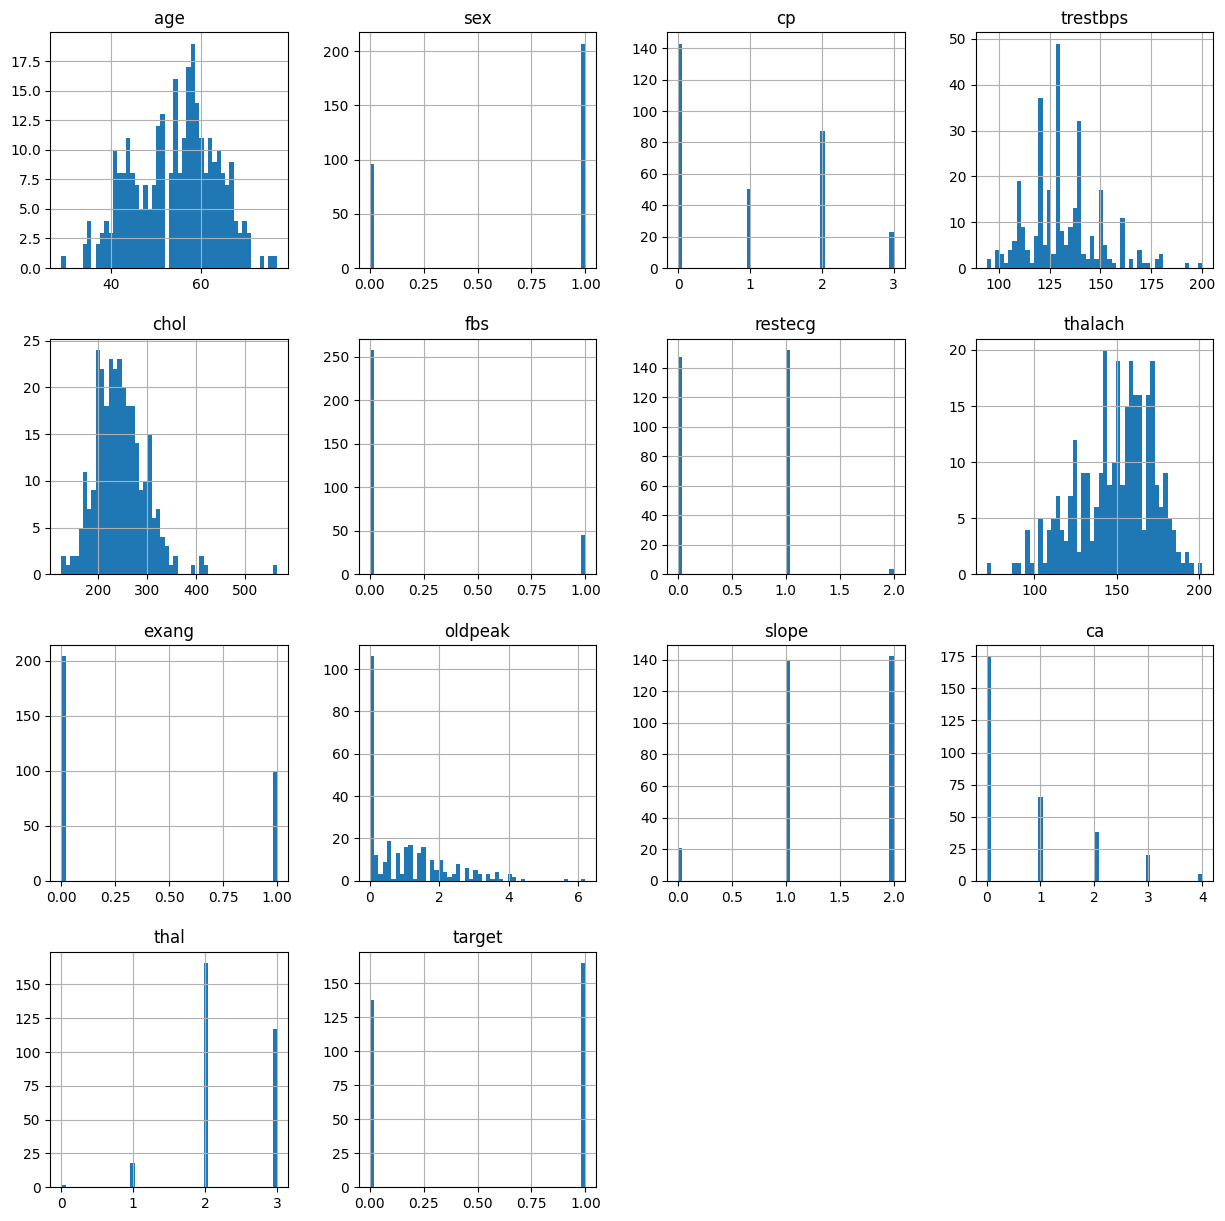

In [127]:

dataset.hist(
    figsize=(15,15),
    bins=50
)

/tmp/ipykernel_7351/3791295465.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(dataset['target'].value_counts(), palette=['red','blue'])


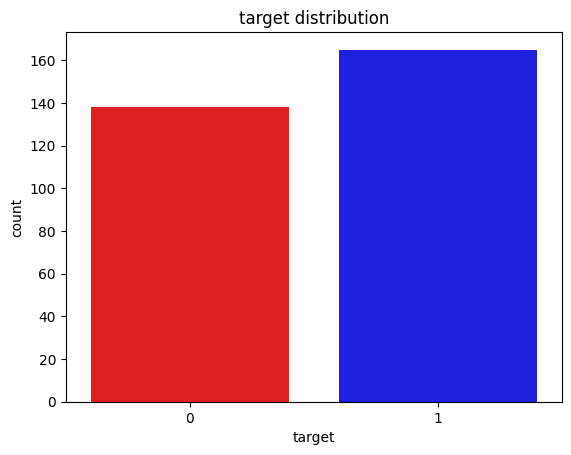

In [128]:
sns.barplot(dataset['target'].value_counts(), palette=['red','blue'])
plt.xlabel('target')
plt.ylabel('count')
plt.title('target distribution')
plt.show()

<Axes: >

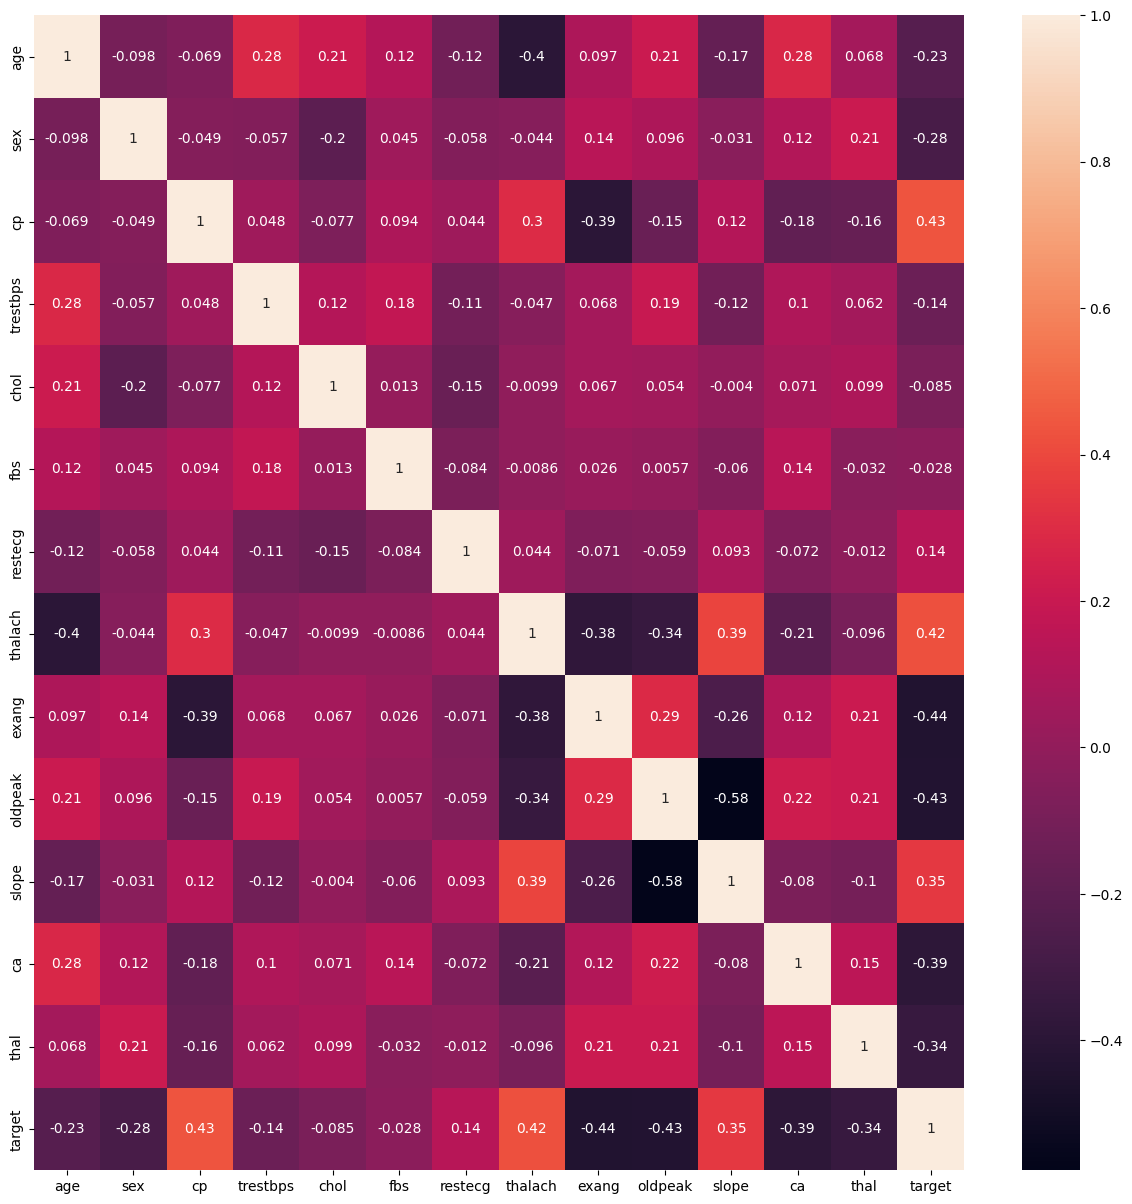

In [129]:
## correlation

plt.figure(figsize=(15,15))
sns.heatmap(dataset.corr(),annot=True)

In [130]:
#train test split

X = dataset.drop(['target'],axis=1)
y = dataset['target']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)



In [131]:

cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [132]:
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer(
    [
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols),
        ('scaler', StandardScaler(), num_cols)

    ],
    remainder='passthrough'

)
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

In [133]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, ReLU, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

In [134]:
model = Sequential()

model.add(
    Dense(
        units=8,
        activation='relu',
        kernel_regularizer=regularizers.L2(0.01)
    ),
    Dropout(0.1)
)

model.add(
    Dense(
        units=16,
        activation='relu',
        kernel_regularizer=regularizers.L2(0.01)

    ),
    Dropout(0.1)

)
model.add(
    Dense(
        units=4,
        activation='relu',
        kernel_regularizer=regularizers.L2(0.01)

    )
)
model.add(
    Dense(
        units=2,
        activation='relu',
        kernel_regularizer=regularizers.L2(0.01)

    )
)

model.add(
    Dense(
        units=1,
        activation='sigmoid'

    )
)

for reduce overfitting at that time we must apply dropout and regularization

In [135]:
opt = Adam(learning_rate=0.01)

In [136]:
model.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [137]:
## Early stopping
import tensorflow as tf
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [138]:
model_history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.5130 - loss: 0.9680 - val_accuracy: 0.5714 - val_loss: 0.8858
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5440 - loss: 0.8330 - val_accuracy: 0.5714 - val_loss: 0.7799
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5492 - loss: 0.7323 - val_accuracy: 0.6531 - val_loss: 0.7114
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7824 - loss: 0.6717 - val_accuracy: 0.7347 - val_loss: 0.6602
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7927 - loss: 0.6342 - val_accuracy: 0.6939 - val_loss: 0.6305
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7979 - loss: 0.6052 - val_accuracy: 0.6939 - val_loss: 0.6171
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8031 - loss: 0.5939 - val_accuracy: 0.7551 - val_loss: 0.5969
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8238 - loss: 0.5727 - val_accuracy: 0.7551 - val_loss:

In [139]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

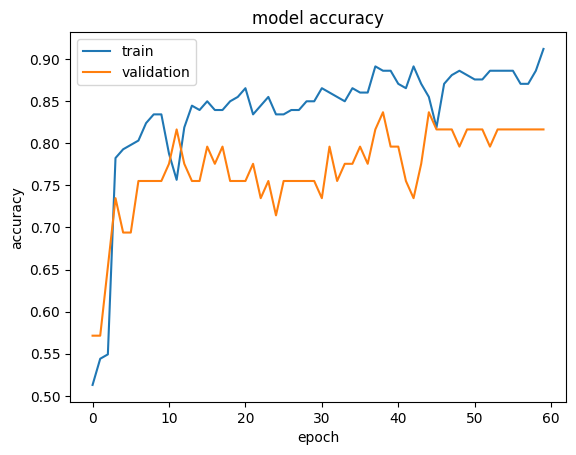

In [140]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'])
plt.show()

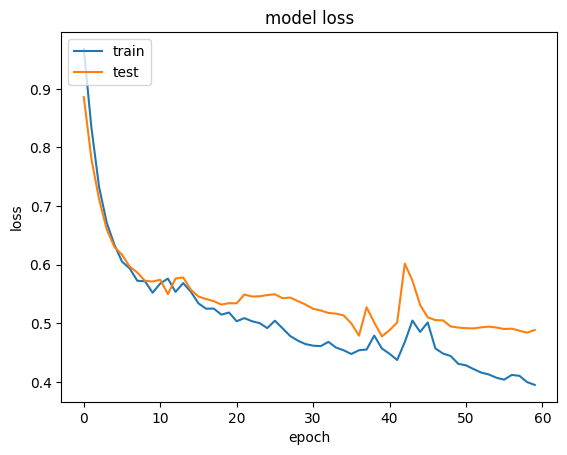

In [141]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')

In [142]:
# predicting the test set results
y_pred = model.predict(X_test)
y_pred = (y_pred >= 0.5)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


In [143]:
## calculate the accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)

In [144]:
score

0.8688524590163934